# Genetic Algorithm - Maximizing f(x) = x^2 over 5-bit Encoded Population

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

### Encoding scheme - 5-bit binary string represents integers 0 to 31

In [2]:
def decode(bitstring):
    return int(bitstring, 2)

print("00000 ->", decode("00000"))
print("11111 ->", decode("11111"))

00000 -> 0
11111 -> 31


### Initial population and fitness, f(x) = x^2

In [3]:
population = ["10101", "11100", "01011", "10010"]

def fitness(bitstring):
    return decode(bitstring) ** 2

values = [decode(s) for s in population]
fit = [fitness(s) for s in population]
gen1 = pd.DataFrame({"string": population, "x": values, "f(x)=x^2": fit})
print(gen1)

total_fit = sum(fit)
avg_fit = total_fit / len(fit)
max_fit = max(fit)
print("Total fitness:", total_fit, " Average fitness:", avg_fit, " Max fitness:", max_fit)

  string   x  f(x)=x^2
0  10101  21       441
1  11100  28       784
2  01011  11       121
3  10010  18       324
Total fitness: 1670  Average fitness: 417.5  Max fitness: 784


### Selection probability and expected count (roulette wheel method)

In [4]:
probs = [f / total_fit for f in fit]
expected_counts = [f / avg_fit for f in fit]
gen1["probability"] = [round(p, 4) for p in probs]
gen1["expected count"] = [round(e, 4) for e in expected_counts]
print(gen1)
print("Sum of probabilities:", sum(probs))
print("Sum of expected counts:", sum(expected_counts))

  string   x  f(x)=x^2  probability  expected count
0  10101  21       441       0.2641          1.0563
1  11100  28       784       0.4695          1.8778
2  01011  11       121       0.0725          0.2898
3  10010  18       324       0.1940          0.7760
Sum of probabilities: 1.0
Sum of expected counts: 4.0


### Round expected counts to whole numbers of copies summing to population size

In [5]:
floors = [math.floor(e) for e in expected_counts]
remainders = [e - math.floor(e) for e in expected_counts]
deficit = len(population) - sum(floors)
order_by_remainder = sorted(range(len(population)), key=lambda i: -remainders[i])
actual_counts = floors[:]
for i in range(deficit):
    actual_counts[order_by_remainder[i]] += 1
gen1["actual count"] = actual_counts
print(gen1)

  string   x  f(x)=x^2  probability  expected count  actual count
0  10101  21       441       0.2641          1.0563             1
1  11100  28       784       0.4695          1.8778             2
2  01011  11       121       0.0725          0.2898             0
3  10010  18       324       0.1940          0.7760             1


### Build the mating pool from the actual counts

In [6]:
mating_pool = []
for s, count in zip(population, actual_counts):
    mating_pool.extend([s] * count)
print("Mating pool:", mating_pool)

Mating pool: ['10101', '11100', '11100', '10010']


### Single-point crossover, pairing consecutive members of the mating pool

In [7]:
crossover_point = 2

def crossover(parent1, parent2, point):
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

offspring = []
for i in range(0, len(mating_pool), 2):
    p1, p2 = mating_pool[i], mating_pool[i + 1]
    c1, c2 = crossover(p1, p2, crossover_point)
    print(f"Parents: {p1} , {p2}  ->  cut after bit {crossover_point}  ->  offspring: {c1} , {c2}")
    offspring.extend([c1, c2])

print("Population after crossover:", offspring)

Parents: 10101 , 11100  ->  cut after bit 2  ->  offspring: 10100 , 11101
Parents: 11100 , 10010  ->  cut after bit 2  ->  offspring: 11010 , 10100
Population after crossover: ['10100', '11101', '11010', '10100']


### Mutation - flip a single bit on one individual, as a demonstration

In [8]:
mutate_index = 2
bit_to_flip = 0
original = offspring[mutate_index]
flipped_bit = "1" if original[bit_to_flip] == "0" else "0"
mutated = flipped_bit + original[1:]
print(f"Mutating individual {mutate_index}: {original} -> flip bit {bit_to_flip+1} -> {mutated}")
offspring[mutate_index] = mutated

new_population = offspring
print("New population (generation 2):", new_population)

Mutating individual 2: 11010 -> flip bit 1 -> 01010
New population (generation 2): ['10100', '11101', '01010', '10100']


### Evaluate the new generation

In [9]:
new_values = [decode(s) for s in new_population]
new_fit = [fitness(s) for s in new_population]
gen2 = pd.DataFrame({"string": new_population, "x": new_values, "f(x)=x^2": new_fit})
print(gen2)

new_total = sum(new_fit)
new_avg = new_total / len(new_fit)
new_max = max(new_fit)
print("Generation 1 -> Generation 2")
print("Average fitness:", avg_fit, "->", new_avg)
print("Max fitness:", max_fit, "->", new_max)

  string   x  f(x)=x^2
0  10100  20       400
1  11101  29       841
2  01010  10       100
3  10100  20       400
Generation 1 -> Generation 2
Average fitness: 417.5 -> 435.25
Max fitness: 784 -> 841


### Plot fitness before and after one generation

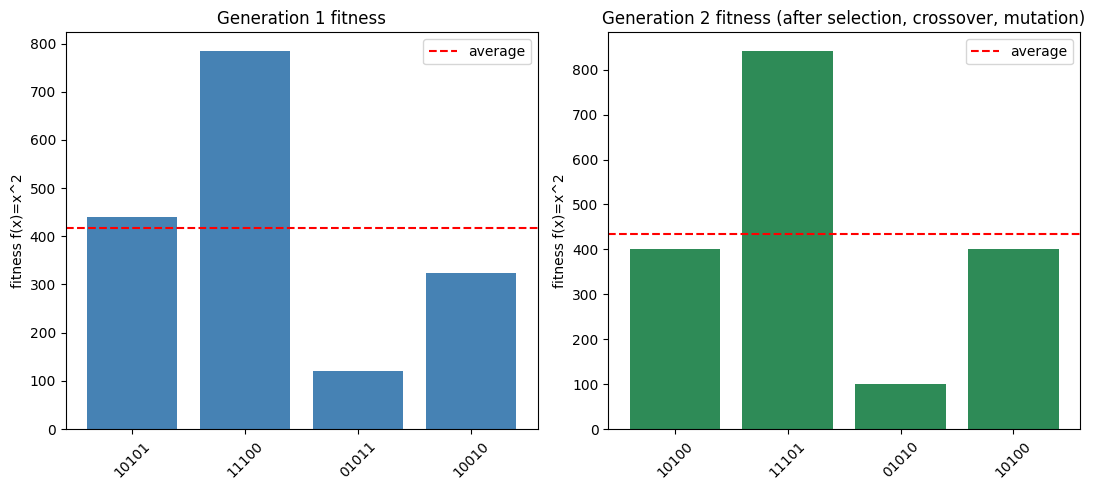

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(range(len(fit)), fit, color="steelblue")
axes[0].set_xticks(range(len(fit)))
axes[0].set_xticklabels(population, rotation=45)
axes[0].set_ylabel("fitness f(x)=x^2")
axes[0].set_title("Generation 1 fitness")
axes[0].axhline(avg_fit, color="red", linestyle="--", label="average")
axes[0].legend()

axes[1].bar(range(len(new_fit)), new_fit, color="seagreen")
axes[1].set_xticks(range(len(new_fit)))
axes[1].set_xticklabels(new_population, rotation=45)
axes[1].set_ylabel("fitness f(x)=x^2")
axes[1].set_title("Generation 2 fitness (after selection, crossover, mutation)")
axes[1].axhline(new_avg, color="red", linestyle="--", label="average")
axes[1].legend()

plt.tight_layout()
plt.show()